In [1]:
library(tidyverse)
library(cowplot)

stage_colors <- c(immature = "#93C572", mature = "#3F7A43")
outline      <- "grey25"

theme_set(theme_cowplot(font_size = 12))
options(repr.plot.width = 8, repr.plot.height = 4.5)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
density <- read_csv("data/trichome_density.csv", show_col_types = FALSE)

density$stage <- factor(density$stage, levels = c("immature", "mature"))

density

zone,stage,count,image,field_mm2,density_per_mm2
<chr>,<fct>,<dbl>,<chr>,<dbl>,<dbl>
throat,immature,145,ithf50x,4.9152,29.500326
throat,mature,89,mthf50x,4.9152,18.107096
stomach,immature,75,istf50x,4.9152,15.258789
stomach,mature,40,msf50x,4.9152,8.138021


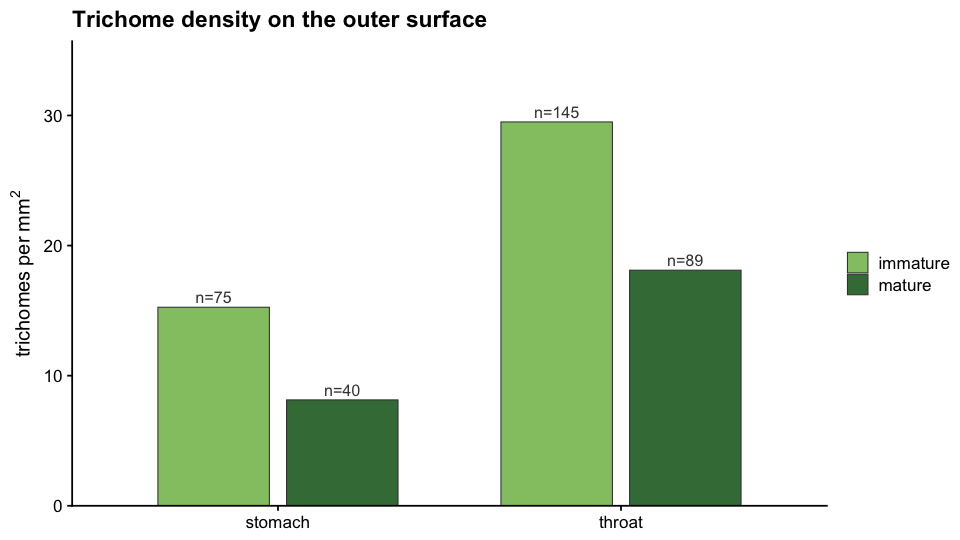

In [3]:
plot1 <- ggplot(density, aes(x = zone, y = density_per_mm2, fill = stage)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65,
           colour = outline, linewidth = 0.3) +
  geom_text(aes(label = paste0("n=", count)),
            position = position_dodge(width = 0.75),
            vjust = -0.4, size = 3.4, colour = "grey25") +
  scale_fill_manual(values = stage_colors) +
  scale_y_continuous(limits = c(0, 34), expand = expansion(mult = c(0, 0.05))) +
  labs(title = "Trichome density on the outer surface",
       x = NULL, y = expression(trichomes~per~mm^2), fill = NULL)

plot1
ggsave("output/trichome_density.png", plot1, width = 7, height = 4.5, dpi = 300)

In [4]:
density %>%
  select(zone, stage, density_per_mm2) %>%
  pivot_wider(names_from = stage, values_from = density_per_mm2) %>%
  mutate(immature_over_mature = immature / mature) -> ratios

as.data.frame(ratios)

zone,immature,mature,immature_over_mature
<chr>,<dbl>,<dbl>,<dbl>
throat,29.50033,18.107096,1.629213
stomach,15.25879,8.138021,1.875000
